In [1]:
import numpy as np
import matplotlib.pyplot as plt

from numpy import poly1d, polyfit


In [2]:
data = np.loadtxt("model_penergy.out")

In [3]:
import subprocess
ROOT = subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip()

reference = f"{ROOT}/DATASETS/C/GAP2020/config_types/Diamond/eperatom_cubiclp.txt"
reference_data = np.loadtxt(reference)

<>:104: SyntaxWarning: invalid escape sequence '\p'
<>:104: SyntaxWarning: invalid escape sequence '\A'
<>:145: SyntaxWarning: invalid escape sequence '\A'
<>:104: SyntaxWarning: invalid escape sequence '\p'
<>:104: SyntaxWarning: invalid escape sequence '\A'
<>:145: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_126579/2604219255.py:104: SyntaxWarning: invalid escape sequence '\p'
  label=f"Experimental: {experimental_value:.5f} $\pm$ {experimental_uncertainty:.5f} $\AA$",
/tmp/ipykernel_126579/2604219255.py:104: SyntaxWarning: invalid escape sequence '\A'
  label=f"Experimental: {experimental_value:.5f} $\pm$ {experimental_uncertainty:.5f} $\AA$",
/tmp/ipykernel_126579/2604219255.py:145: SyntaxWarning: invalid escape sequence '\A'
  ax.set_xlabel("Nearest Neighbor Distance ($\AA$)")


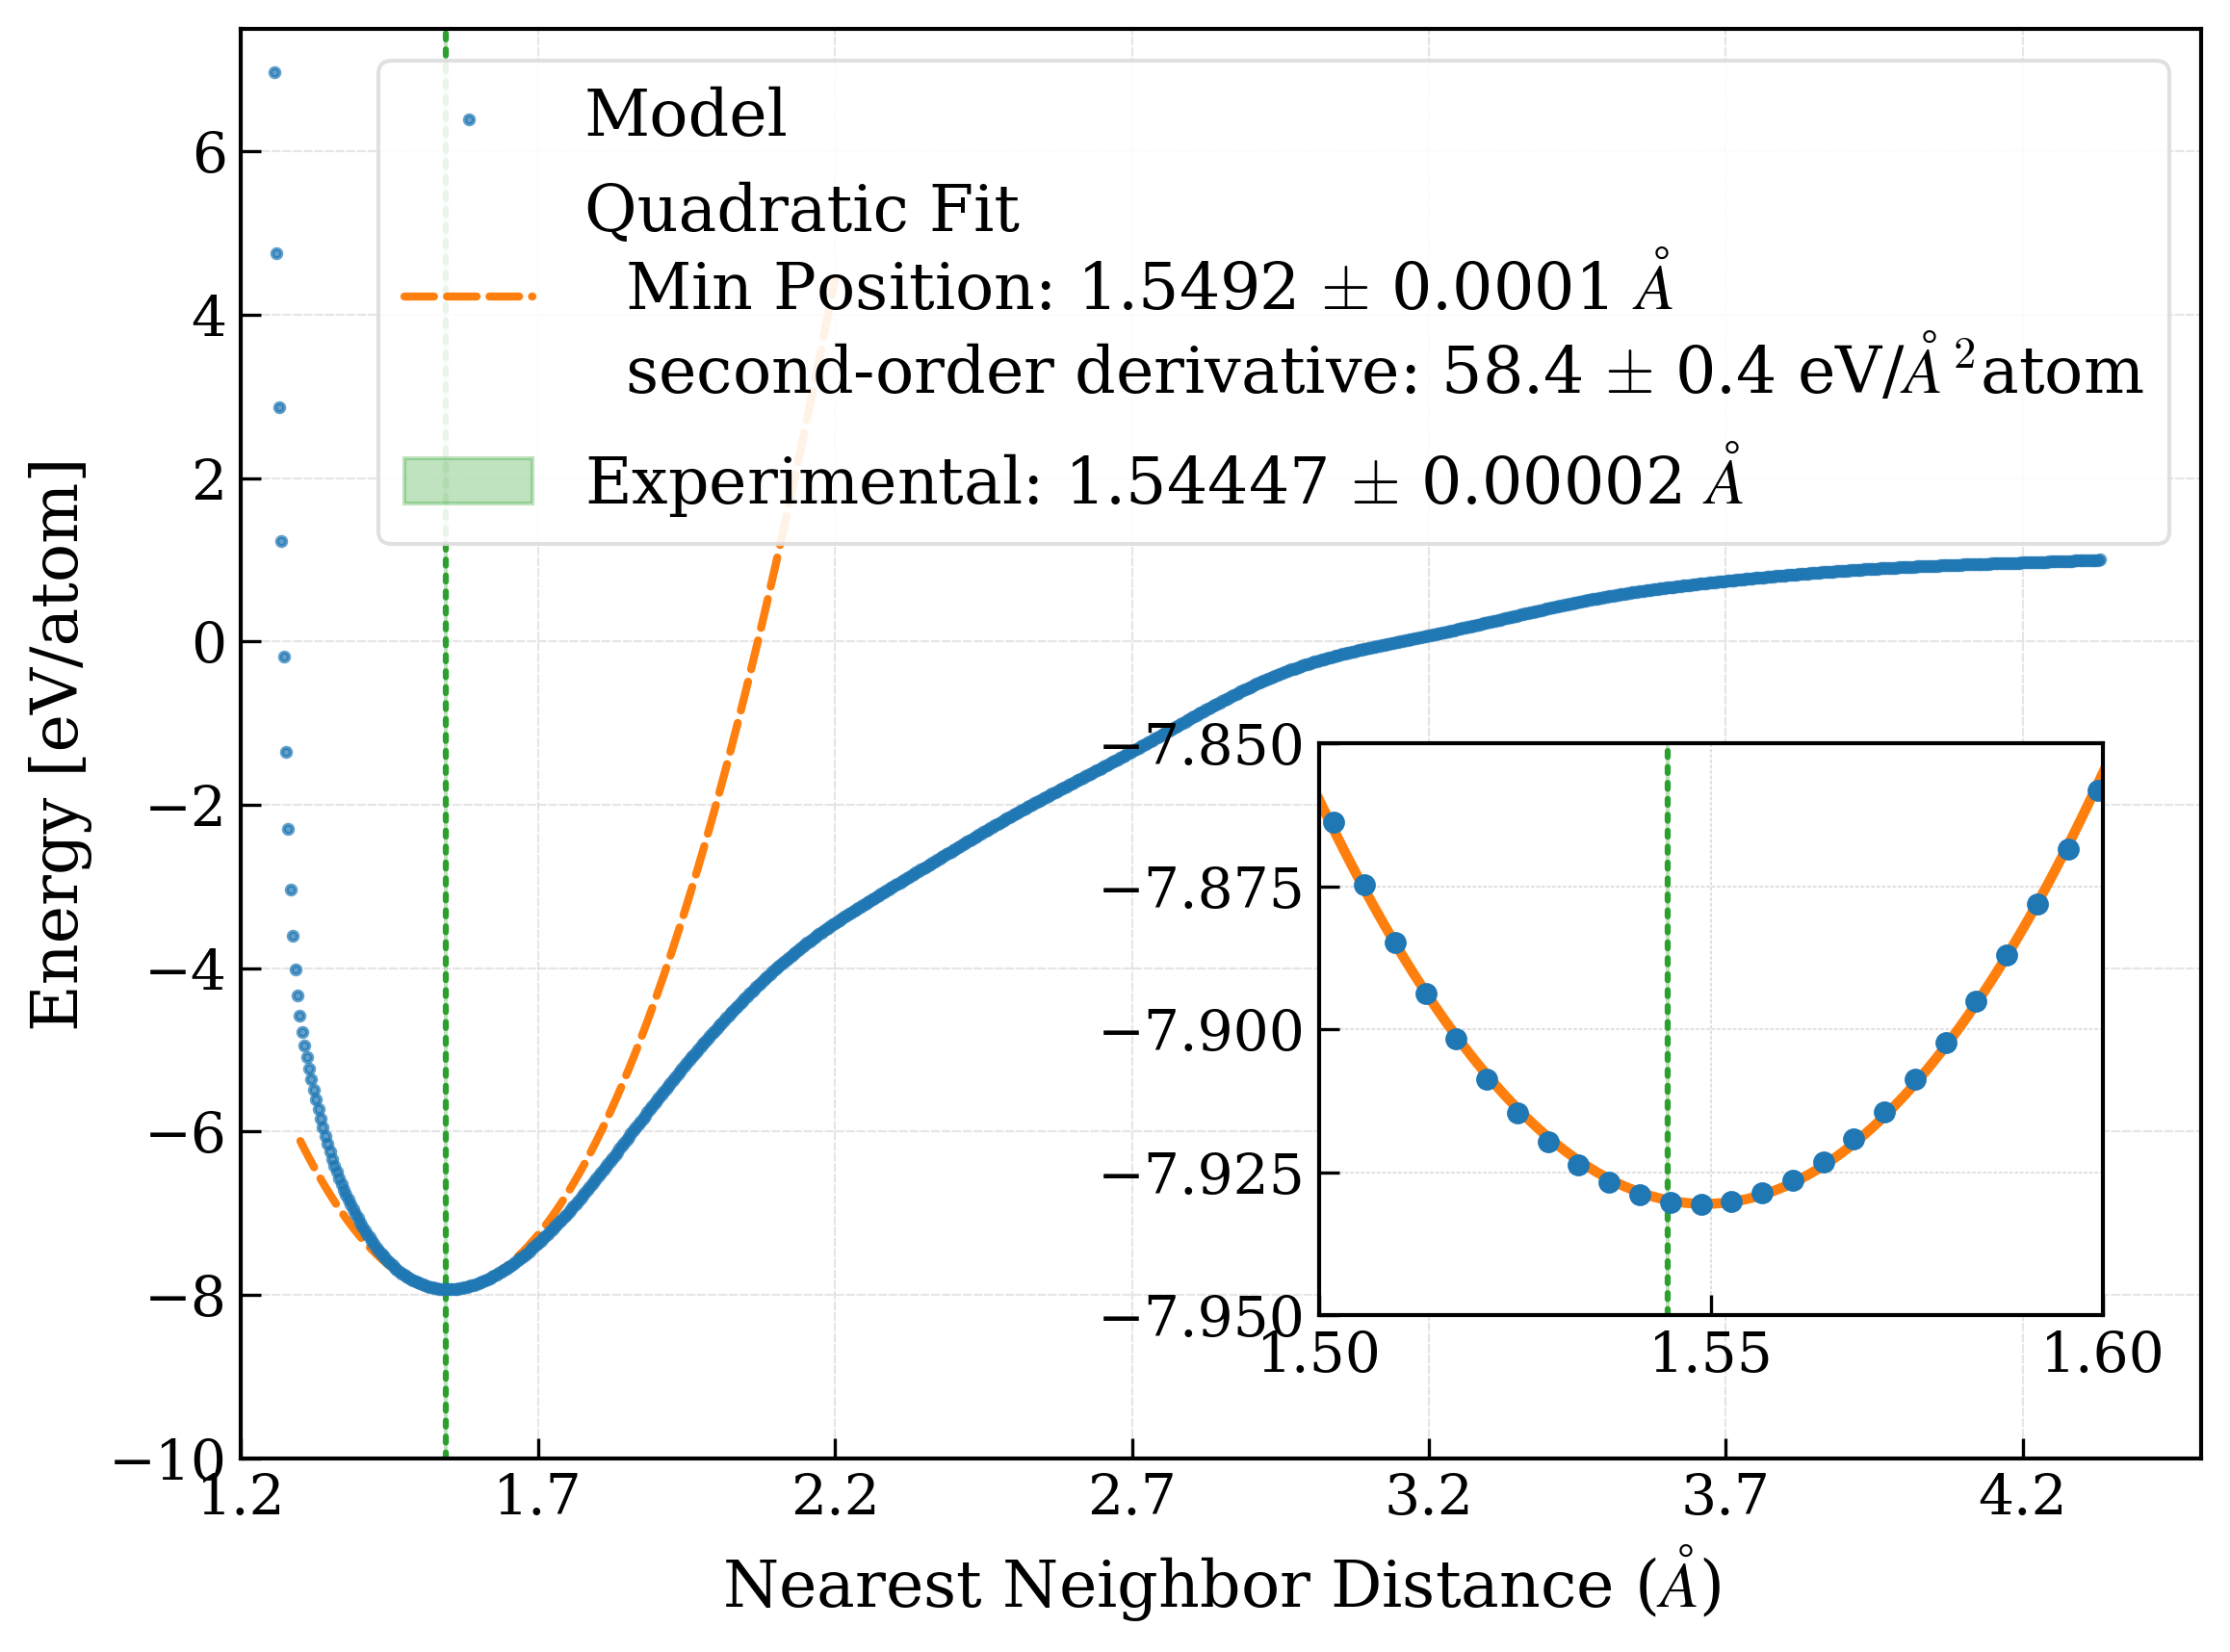

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from numpy import polyfit, poly1d

experimental_value = 1.54447
experimental_uncertainty = 0.000016 * 1.00202

# Dummy data placeholder — replace with your actual 'data' matrix
# data = np.random.rand(1000, 2) 

# ==========================================
# 1. SETUP & INITIALIZATION
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6))
scale = np.sqrt(3) / 4

# Scale the raw data axes directly for plotting consistency
x_scaled = data[:, 0] * scale
y_scaled = data[:, 1] / 2.0

# FIX: Added rasterized=True to fix the PDF rendering bug, 
# changed edgecolors to 'face', and set zorder=2 to place it on top.
ax.scatter(
    x_scaled, y_scaled, 
    label="Model", 
    color="#1f77b4", 
    alpha=0.7, 
    edgecolors='face', 
    s=5, 
    zorder=2,
    rasterized=True
)

# ==========================================
# 2. DATA FILTERING & POLYNOMIAL FITTING
# ==========================================
# Clean Inset Limits (defined in scaled units)
quadratic_limits = (1.5, 1.6)

# Masking using the scaled X values to target the zoom window
mask = (x_scaled > quadratic_limits[0]) & (x_scaled < quadratic_limits[1])
row_indices = np.where(mask)[0]

x_fit_pts = x_scaled[row_indices]
y_fit_pts = y_scaled[row_indices]

# Fit 2nd-degree polynomial to the scaled data window
# coeffs order: [a, b, c] for ax^2 + bx + c
coeffs, covar = polyfit(x_fit_pts, y_fit_pts, deg=2, cov=True)
poly2 = poly1d(coeffs)

# ==========================================
# 3. DERIVATIVE & MINIMUM CALCULATIONS WITH UNCERTAINTIES
# ==========================================
a, b, c = coeffs

# Extract variances and covariance from the fit matrix
# Indexing maps to [a, b, c]
var_a = covar[0, 0]
var_b = covar[1, 1]
cov_ab = covar[0, 1]

# 1. Minimum Position x_min = -b / (2a)
x_min = -b / (2 * a)
y_min = poly2(x_min)

# Error propagation for x_min: f(a,b) = -b / (2a)
# partial_a = b / (2 * a^2), partial_b = -1 / (2 * a)
df_da = b / (2 * (a ** 2))
df_db = -1 / (2 * a)
x_min_err = np.sqrt((df_da ** 2) * var_a + (df_db ** 2) * var_b + 2 * df_da * df_db * cov_ab)

# 2. Second-order derivative d^2E/dx^2 = 2a
d2E_dx2_scaled = 2 * a  
d2E_dx2_scaled_err = 2 * np.sqrt(var_a) # linear scaling of standard deviation

# 3. Rescaled back relative to the original unscaled data matrix axis
d2E_dx2_raw = d2E_dx2_scaled * (scale ** 2)

# ==========================================
# 4. MAIN PLOT ADDITIONS
# ==========================================
# Generate a wider X range for the main plot parabola
x_wide = np.linspace(1.3, 2.2, 200)

fit_label = (
    f"Quadratic Fit\n"
    rf"  Min Position: {x_min:.4f} $\pm$ {x_min_err:.4f} $\AA$"
    "\n"
    rf"  second-order derivative: {d2E_dx2_scaled:.1f} $\pm$ {d2E_dx2_scaled_err:.1f} eV/$\AA^2$atom"
)
# FIX: Set zorder=1 so the line passes underneath the data points
ax.plot(x_wide, poly2(x_wide), color="#ff7f0e", linestyle="--", linewidth=2, label=fit_label, zorder=1)

# --- EXPERIMENTAL VALUE & UNCERTAINTY (MAIN PLOT) ---
exp_low = experimental_value - experimental_uncertainty
exp_high = experimental_value + experimental_uncertainty

# Add the shaded region (zorder=0 puts it behind lines/scatter points)
ax.axvspan(
    exp_low, exp_high, 
    color="#2ca02c", 
    alpha=0.3, 
    label=f"Experimental: {experimental_value:.5f} $\pm$ {experimental_uncertainty:.5f} $\AA$", 
    zorder=0
)
# Add a vertical guideline since the uncertainty window is extremely thin
ax.axvline(experimental_value, color="#2ca02c", linestyle=":", linewidth=1.5, zorder=1)

# ==========================================
# 5. INSET SETUP & ZOOM
# ==========================================
axins = ax.inset_axes([0.55, 0.1, 0.4, 0.4]) 

# FIX: Added rasterized=True and zorder=2 to mirror the main axes fixes
axins.scatter(
    x_scaled, y_scaled, 
    color="#1f77b4", 
    s=20, 
    edgecolors='face',
    zorder=2,
    rasterized=True
)

# Plot the fitted parabola segment tightly inside the inset
x_ins_fit = np.linspace(quadratic_limits[0], quadratic_limits[1], 100)
# FIX: Set zorder=1 for the inset line
axins.plot(x_ins_fit, poly2(x_ins_fit), color="#ff7f0e", linewidth=2.5, zorder=1)

# --- EXPERIMENTAL VALUE & UNCERTAINTY (INSET) ---
axins.axvspan(exp_low, exp_high, color="#2ca02c", alpha=0.3, zorder=0)
axins.axvline(experimental_value, color="#2ca02c", linestyle=":", linewidth=1.5, zorder=1)

# Set tight bounds on the inset to look directly at the valley minimum
axins.set_xlim(quadratic_limits) 
axins.set_ylim(-7.95, -7.85)
axins.grid(True, linestyle=":", alpha=0.6)

# Draw the connector lines from the main plot box to the inset axes
# ax.indicate_inset_zoom(axins, edgecolor="gray", alpha=0.5)

# ==========================================
# 6. GLOBAL FORMATTING & EXPORT
# ==========================================
ax.set_xlabel("Nearest Neighbor Distance ($\AA$)")
ax.set_ylabel("Energy [eV/atom]")
ax.set_ylim(-10, 7.5)
ax.set_xlim(1.2, 4.5)
ax.set_xticks(np.arange(1.2, 4.6, 0.5))

ax.legend(loc="upper right", framealpha=0.9)
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("BM_diamond_lp_scan.pdf", bbox_inches="tight")
plt.show()